Q: Calculate the membrane resting potential for the values in the table above of ion specific permeabilities (P) and 
intracellular (Cin) and extracellular (Cout) ion concentrations (in mol/l, “molar” designated by M).

In [10]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:


F = 96480 
R = 8.314 
T = 293
numerator = 400 + 50 + 5
denominator= 10 + 460 + 40

V_rest = (R*T/F)*np.log(numerator/denominator) 
print(V_rest)



-0.0028812214294366817


Q: Interchange the Cin with Cout  for all ions and calculate resting potential again. How does it relate to the above?

In [3]:


F = 96480 
R = 8.314 
T = 293
numerator = 400 + 50 + 5
denominator= 10 + 460 + 40

V_rest = (R*T/F)*np.log(denominator/numerator) 
print(V_rest)



0.0028812214294366835


A: Flipped sign via the log.

Q:What is the resting potential if only the K permeability is non-zero?

In [4]:
F = 96480 
R = 8.314 
T = 293
numerator = 400 
denominator= 10 

V_rest = (R*T/F)*np.log(numerator/denominator) 
print(V_rest)

0.09313969452716062


Q:What is the resting potential if only the Na permeability is non-zero?

In [5]:
F = 96480 
R = 8.314 
T = 293
numerator = 50
denominator= 460

V_rest = (R*T/F)*np.log(numerator/denominator) 
print(V_rest)

-0.05603217377243921


print("hej")

In [6]:
import numpy as np

F = 96485
R = 8.314
T = 310

def eta(z, V, F, R, T):
    return z * V * F / (R * T)

def I(V, P, z, F, R, T, C_in, C_out):
    et = eta(z, V, F, R, T)

    if V == 0:
        return P * z * F * (C_in - C_out)

    exp_et = np.exp(-et)

    return (
        P * z * F * et
        * (C_in - C_out * exp_et)
        / (1 - exp_et)
    )

z_ls = [1, 1, -1]
P_ls = [4e-9, 0.12e-9, 0.4e-9]
in_ls = [400, 50, 40]
out_ls = [10, 100, 65]

V = -70e-3

I_sum = 0

for i in range(3):
    print("starting", i)

    curr_i = I(
        V, P_ls[i], z_ls[i],
        F, R, T,
        in_ls[i], out_ls[i]
    )

    print("finished", i, curr_i)
    I_sum += curr_i

print("Total:", I_sum)

starting 0
finished 0 0.02083971113215445
starting 1
finished 1 -0.003153132234813572
starting 2
finished 2 -0.003847022683674893
Total: 0.013839556213665987


Q:What is the dimension of I_m?
A: [I_m] = A/m^2

ADD EXPLANATION?

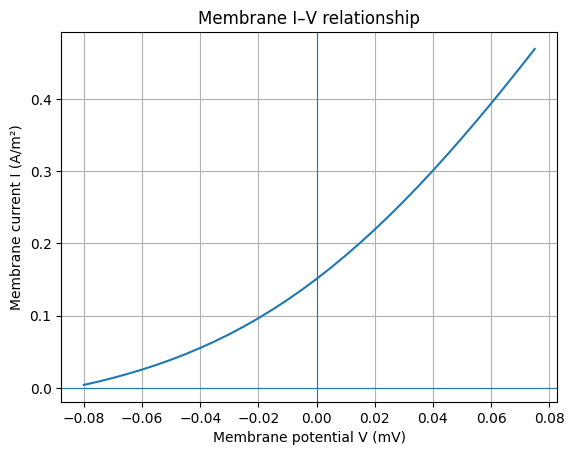

In [ ]:

I_list =[]
V_list = [ v*10**(-3) for v in range(-80,81,5) ]
for v in V_list:
    I_sum =0
    for i in range(3):

        curr_i = I(
            v, P_ls[i], z_ls[i],
            F, R, T,
            in_ls[i], out_ls[i]
        )

        I_sum += curr_i
    I_list.append(I_sum)

plt.plot(V_list, I_list)

plt.xlabel("Membrane potential V (V)")
plt.ylabel("Membrane current I (A/m²)")
plt.title("Membrane I–V relationship")
plt.grid(True)
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.show()